In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
path_to_data = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
column_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep']

In [2]:
df = pd.read_csv(path_to_data, names=column_names)
target_column = 'accep'
raw_feature_columns = [col for col in column_names if col != target_column]
print("Dataset shape:", df.shape)


Dataset shape: (1728, 7)


In [3]:
# One-hot encode categorical features
X = pd.get_dummies(df[raw_feature_columns], drop_first=True)
# Convert target column to binary variable (0 if 'unacc', 1 otherwise)
df[target_column] = np.where(df[target_column] == 'unacc', 0, 1)
y = df[target_column]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=123, test_size=0.3
)


In [4]:
#Create Gradient Boosted Trees classifier with 15 estimators
grad_classifier = GradientBoostingClassifier(n_estimators=15, random_state=123)
#parameters
print("Gradient Boosted Trees Parameters:\n", grad_classifier.get_params())
#Fit the model and predict
grad_classifier.fit(X_train, y_train)
y_pred = grad_classifier.predict(X_test)


Gradient Boosted Trees Parameters:
 {'ccp_alpha': 0.0, 'criterion': 'deprecated', 'init': None, 'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 15, 'n_iter_no_change': None, 'random_state': 123, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


In [5]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [6]:
print("\nModel Performance:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))



Model Performance:
Accuracy: 0.8979
Precision: 0.7886
Recall: 0.8961
F1 Score: 0.8389


In [7]:
#Confusion matrix (raw and formatted)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (raw):\n", conf_matrix)

test_conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=[1, 0]),
    index=['Actual Yes', 'Actual No'],
    columns=['Predicted Yes', 'Predicted No']
)
print("\nConfusion Matrix (formatted):\n", test_conf_matrix.to_string())



Confusion Matrix (raw):
 [[328  37]
 [ 16 138]]

Confusion Matrix (formatted):
             Predicted Yes  Predicted No
Actual Yes            138            16
Actual No              37           328


In [8]:
#Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Feature importances
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': grad_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nTop 5 Features:\n", importances.head(5))



Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.93       365
           1       0.79      0.90      0.84       154

    accuracy                           0.90       519
   macro avg       0.87      0.90      0.88       519
weighted avg       0.90      0.90      0.90       519


Top 5 Features:
          Feature  Importance
10  persons_more    0.342878
13    safety_low    0.339310
9      persons_4    0.136199
5    maint_vhigh    0.086691
2   buying_vhigh    0.038270


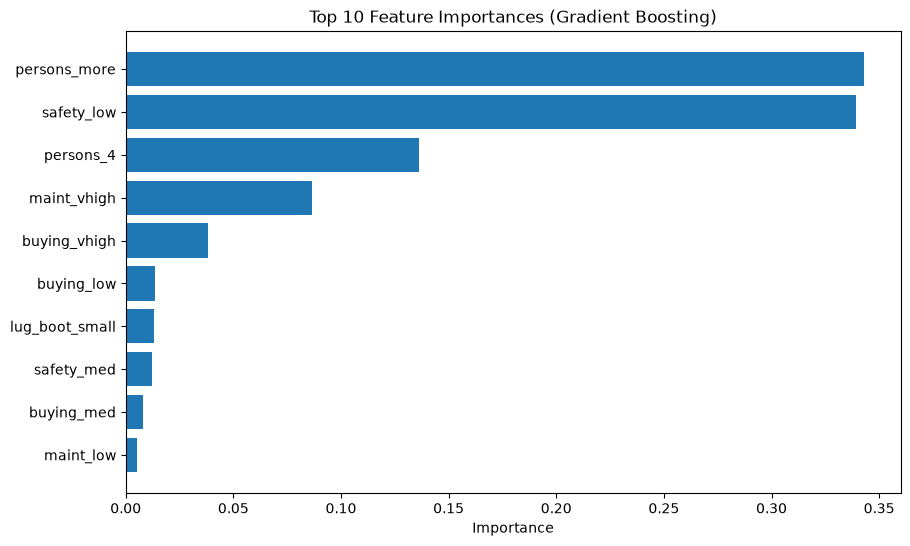

In [9]:
#Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][:10], importances['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.show()
